In [3]:
import pandas as pd   #used for data manipulation
import numpy as np   #used for numerical operations

In [4]:
# Load the dataset
cars_data = pd.read_csv('data_saudi_used_cars.csv')
cars_data.head()  # Display the first few rows of the dataset

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0


In [90]:
cars_data.head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0


In [8]:
#Display the shape of the dataset
cars_data.shape

(5624, 11)

In [92]:
# Display information about the dataset, including data types and non-null counts
cars_data.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5624 entries, 0 to 5623
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Type         5624 non-null   object 
 1   Region       5624 non-null   object 
 2   Make         5624 non-null   object 
 3   Gear_Type    5624 non-null   object 
 4   Origin       5624 non-null   object 
 5   Options      5624 non-null   object 
 6   Year         5624 non-null   int64  
 7   Engine_Size  5624 non-null   float64
 8   Mileage      5624 non-null   int64  
 9   Negotiable   5624 non-null   bool   
 10  Price        5624 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 445.0+ KB


In [56]:
cars_data.isnull().sum()  # Check for missing values in each column

Type           0
Region         0
Make           0
Gear_Type      0
Origin         0
Options        0
Year           0
Engine_Size    0
Mileage        0
Negotiable     0
Price          0
dtype: int64

In [9]:
# Check rows with Price represented as'0'
print("Number of Price with 0 value : ",cars_data[cars_data['Price'] ==0]['Price'].count())

Number of Price with 0 value :  1797


In [10]:
# Check Duplicate Values

display(cars_data[cars_data.duplicated()])
print(f"Number of Duplicate Values: {sum(cars_data.duplicated())} records")

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
953,Rio,Riyadh,Kia,Automatic,Saudi,Standard,2016,1.4,270000,False,25000
4646,Sonata,Jeddah,Hyundai,Automatic,Saudi,Standard,2020,2.4,100,False,72910
4933,Tucson,Dammam,Hyundai,Automatic,Saudi,Standard,2016,2.0,155000,False,45000
5267,Camry,Riyadh,Toyota,Automatic,Saudi,Full,2013,2.5,185000,True,0


Number of Duplicate Values: 4 records


In [11]:
# Get summary statistics for numerical columns
print("Describe Numerical Features")
display(cars_data.describe().astype('int64'))  

Describe Numerical Features


,Year,Engine_Size,Mileage,Price
count,5624,5624,5624,5624
mean,2014,3,150923,53074
std,5,1,382835,70155
min,1963,1,100,0
25%,2012,2,38000,0
50%,2016,3,103000,36500
75%,2018,4,196000,72932
max,2022,9,20000000,850000


In [12]:
# Display summary statistics for categorical features
print("Describe Categorical Features Values") 
display(cars_data.describe(include=['object', 'bool']))

Describe Categorical Features Values


,Type,Region,Make,Gear_Type,Origin,Options,Negotiable
count,5624,5624,5624,5624,5624,5624,5624
unique,347,27,58,2,4,3,2
top,Land Cruiser,Riyadh,Toyota,Automatic,Saudi,Full,False
freq,269,2272,1431,4875,4188,2233,3828


Checking for outliers

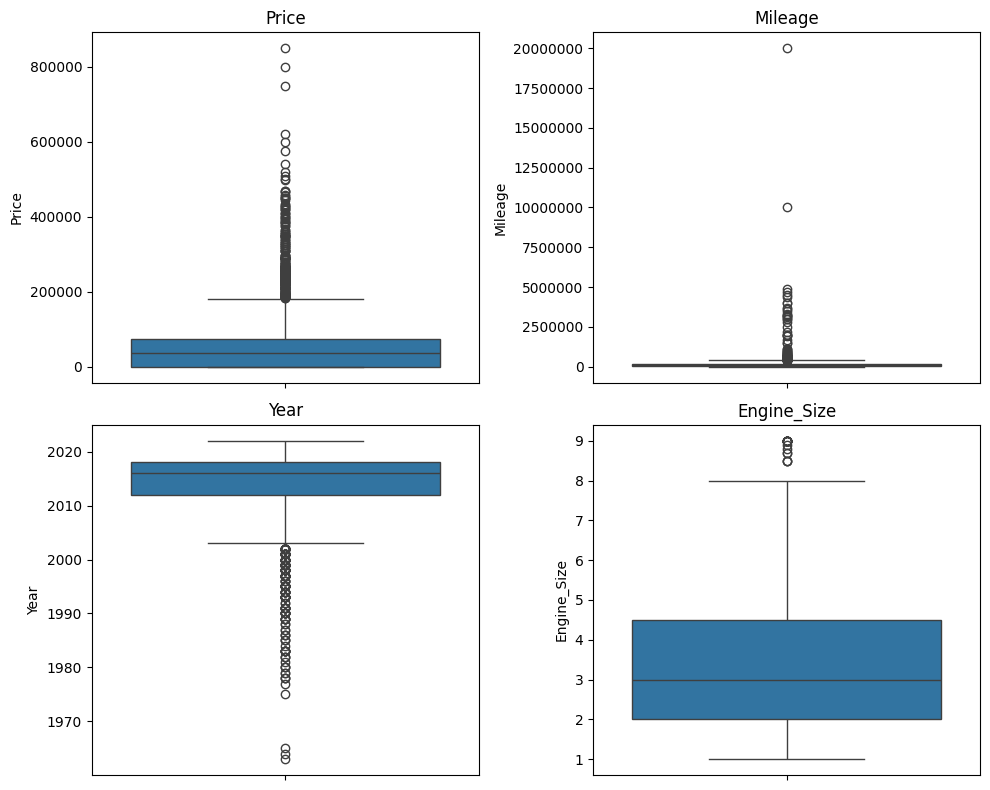

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Combine all graphs into a single figure
plt.figure(figsize=(10, 8))

# Plot for Price
plt.subplot(2, 2, 1)
plt.title('Price')
sns.boxplot(y=cars_data['Price'])
plt.ticklabel_format(useOffset=False, style='plain', axis='y')

# Plot for Mileage
plt.subplot(2, 2, 2)
plt.title('Mileage')
sns.boxplot(y=cars_data['Mileage'])
plt.ticklabel_format(useOffset=False, style='plain', axis='y')

# Plot for Year
plt.subplot(2, 2, 3)
plt.title('Year')
sns.boxplot(y=cars_data['Year'])
plt.ticklabel_format(useOffset=False, style='plain', axis='y')

# Plot for Engine_Size
plt.subplot(2, 2, 4)
plt.title('Engine_Size')
sns.boxplot(y=cars_data['Engine_Size'])
plt.ticklabel_format(useOffset=False, style='plain', axis='y')

# Show the combined figure
plt.tight_layout()
plt.show()


In [14]:
# Check type & amount of Gear Type, Options on Used Cars
print(f"Type & Amount of Gear Type on Used Cars :\
n{cars_data['Gear_Type'].value_counts()}")
print(f"\nType & Amount of Options on Used Cars :\
n{cars_data['Options'].value_counts()}")
print(f"\nType & Amount of Negotiable on Used Cars :\
n{cars_data['Negotiable'].value_counts()}")

Type & Amount of Gear Type on Used Cars :nGear_Type
Automatic    4875
Manual        749
Name: count, dtype: int64

Type & Amount of Options on Used Cars :nOptions
Full         2233
Standard     1822
Semi Full    1569
Name: count, dtype: int64

Type & Amount of Negotiable on Used Cars :nNegotiable
False    3828
True     1796
Name: count, dtype: int64


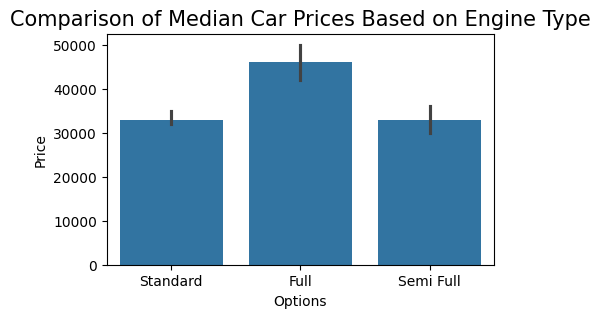

In [15]:
plt.figure(figsize=(5,3))
sns.barplot(x='Options', y='Price', data=cars_data, estimator=np.median)
plt.title('Comparison of Median Car Prices Based on Engine Type', size=15)
plt.show()

In [17]:
cars_data[cars_data.Origin == 'Unknown'].count()

Type           61
Region         61
Make           61
Gear_Type      61
Origin         61
Options        61
Year           61
Engine_Size    61
Mileage        61
Negotiable     61
Price          61
dtype: int64

In [18]:
# Check the unique values in the 'Origin' column
cars_data['Origin'].unique()


array(['Saudi', 'Gulf Arabic', 'Other', 'Unknown'], dtype=object)

Data Cleaning

In [19]:
#Delete the duplicate values
cars_data.drop_duplicates(inplace=True)
display(cars_data[cars_data.duplicated()])
print(f"Number of Duplicate Values: {sum(cars_data.duplicated())} records")

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price


Number of Duplicate Values: 0 records


In [20]:
# Delete the unnecessary columns if they exist
cars_data.drop(['Negotiable'], axis=1, inplace=True)
cars_data.head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0


In [21]:
# inconsistent data ( 'Unknown' = NaN) replace with NaN
cars_data['Origin'].replace('Unknown', np.nan) 

0             Saudi
1             Saudi
2       Gulf Arabic
3             Saudi
4             Saudi
           ...     
5619          Saudi
5620          Saudi
5621          Saudi
5622    Gulf Arabic
5623          Other
Name: Origin, Length: 5620, dtype: object

In [22]:
# Check the unique values in the 'Origin' column again
cars_data = cars_data[cars_data['Price'] != 0]
cars_data
cars_data.sort_values(by='Price', ascending=1, inplace=True)
cars_data.head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
3131,Yukon,Jubail,GMC,Automatic,Saudi,Full,2019,5.3,50000,1
3992,G80,Riyadh,Genesis,Automatic,Other,Semi Full,2018,3.8,170000,500
4399,Yaris,Riyadh,Toyota,Automatic,Saudi,Standard,2018,1.5,100000,850
5128,Rio,Arar,Kia,Automatic,Saudi,Standard,2019,1.4,55500,884
3474,Yaris,Najran,Toyota,Automatic,Saudi,Standard,2019,1.6,85000,950


In [250]:
print(f"Number of records with Price is 0 : {cars_data[cars_data['Price'] == 0].shape[0]}")

Number of records with Price is 0 : 0


In [23]:
# Check the number of records with Price is 0
cars_data['Price'].sort_values()

3131         1
3992       500
4399       850
5128       884
3474       950
         ...  
4653    599000
2120    620000
4273    748000
4684    800000
3513    850000
Name: Price, Length: 3824, dtype: int64

In [24]:
# remove all column with at least one missing value
cars_data = cars_data.dropna(axis=0)


In [25]:
cars_data.isnull().sum()  # Check for missing values in each column

Type           0
Region         0
Make           0
Gear_Type      0
Origin         0
Options        0
Year           0
Engine_Size    0
Mileage        0
Price          0
dtype: int64

In [29]:
def find_anomalies(cars_data):
    q1 = cars_data.quantile(0.25)
    q3 = cars_data.quantile(0.75)
    iqr = q3 - q1
    limit = iqr*1.5
    print(f'IQR: {iqr}')

    lower_limit = q1 - limit
    upper_limit = q3 + limit
    print(f'lower_limit: {lower_limit}')
    print(f'upper_limit: {upper_limit}') 

In [32]:
# Check for outliers in the 'Price', 'Mileage', 'Engine_Size', and 'Year' columns
find_anomalies(cars_data['Price'])    # Check for outliers in the 'Price' column
find_anomalies(cars_data['Mileage'])   # Check for outliers in the 'Mileage' column
find_anomalies(cars_data['Engine_Size'])   # Check for outliers in the 'Engine_Size' column
find_anomalies(cars_data['Year'])  # Check for outliers in the 'Year' column

IQR: 59250.0
lower_limit: -53875.0
upper_limit: 183125.0
IQR: 135000.0
lower_limit: -154500.0
upper_limit: 385500.0
IQR: 2.0
lower_limit: -1.0
upper_limit: 7.0
IQR: 5.0
lower_limit: 2005.5
upper_limit: 2025.5


In [33]:
cars_data['Price'].describe()

count      3824.000000
mean      78019.245031
std       72748.182183
min           1.000000
25%       35000.000000
50%       58000.000000
75%       94250.000000
max      850000.000000
Name: Price, dtype: float64

In [34]:
cars_data['Year'].describe()

count    3824.000000
mean     2014.851203
std         5.110916
min      1963.000000
25%      2013.000000
50%      2016.000000
75%      2018.000000
max      2021.000000
Name: Year, dtype: float64

In [35]:
cars_data['Mileage'].describe()

count    3.824000e+03
mean     1.426211e+05
std      3.783942e+05
min      1.000000e+02
25%      4.800000e+04
50%      1.030000e+05
75%      1.830000e+05
max      2.000000e+07
Name: Mileage, dtype: float64

In [36]:
cars_data['Engine_Size'].describe()

count    3824.000000
mean        3.181119
std         1.458832
min         1.000000
25%         2.000000
50%         2.700000
75%         4.000000
max         9.000000
Name: Engine_Size, dtype: float64

In [37]:
cars_data.describe()  # Display the first few rows of the cleaned dataset

,Year,Engine_Size,Mileage,Price
count,3824.000000,3824.000000,3.824000e+03,3824.000000
mean,2014.851203,3.181119,1.426211e+05,78019.245031
std,5.110916,1.458832,3.783942e+05,72748.182183
min,1963.000000,1.000000,1.000000e+02,1.000000
25%,2013.000000,2.000000,4.800000e+04,35000.000000
50%,2016.000000,2.700000,1.030000e+05,58000.000000
75%,2018.000000,4.000000,1.830000e+05,94250.000000
max,2021.000000,9.000000,2.000000e+07,850000.000000


In [38]:
cars_data.describe()['Price']

count      3824.000000
mean      78019.245031
std       72748.182183
min           1.000000
25%       35000.000000
50%       58000.000000
75%       94250.000000
max      850000.000000
Name: Price, dtype: float64

In [293]:
cars_data

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
3482,Caprice,Riyadh,Chevrolet,Automatic,Saudi,Standard,2006,3.6,380000,5000
3052,Expedition,Al-Medina,Ford,Automatic,Saudi,Semi Full,2003,5.4,400000,5000
2612,Suburban,Aseer,GMC,Automatic,Saudi,Semi Full,1990,3.5,140000,5000
693,Accent,Dammam,Hyundai,Manual,Saudi,Standard,2005,1.5,294602,5000
110,Optra,Riyadh,Chevrolet,Automatic,Saudi,Standard,2007,1.6,2000000,5000
...,...,...,...,...,...,...,...,...,...,...
4057,LX,Dammam,Lexus,Automatic,Other,Full,2013,5.7,98000,200000
2715,The 7,Riyadh,BMW,Automatic,Saudi,Full,2018,2.0,52000,200000
17,Land Cruiser,Riyadh,Toyota,Automatic,Saudi,Full,2019,4.6,71000,200000
4032,LS,Riyadh,Lexus,Automatic,Other,Semi Full,2015,4.6,51000,200000


In [39]:
# Check the number of records with Price is between 5000 and 200000
print(f"Number of records with Price is between 5000 and 200000 : {cars_data[((cars_data['Price'] < 5000) | (cars_data['Price'] > 200000))].shape[0]}")

Number of records with Price is between 5000 and 200000 : 288


In [40]:
# Drop records where Price is under 5000 and over 200000

cars_data = cars_data[~((cars_data['Price'] < 5000) | (cars_data['Price'] > 200000))]
cars_data.sort_values(by='Price', ascending=True).head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
3052,Expedition,Al-Medina,Ford,Automatic,Saudi,Semi Full,2003,5.4,400000,5000
2612,Suburban,Aseer,GMC,Automatic,Saudi,Semi Full,1990,3.5,140000,5000
110,Optra,Riyadh,Chevrolet,Automatic,Saudi,Standard,2007,1.6,2000000,5000
3482,Caprice,Riyadh,Chevrolet,Automatic,Saudi,Standard,2006,3.6,380000,5000
693,Accent,Dammam,Hyundai,Manual,Saudi,Standard,2005,1.5,294602,5000


In [41]:
# Check the number of records with Mileage is between 10000 and 400000
print(f"Number of records with Mileage is between 10000 and 400000 : {cars_data[((cars_data['Mileage'] < 10000) | (cars_data['Mileage'] > 400000))].shape[0]}")

Number of records with Mileage is between 10000 and 400000 : 493


In [42]:
cars_data = cars_data[~((cars_data['Mileage'] < 10000) | (cars_data['Mileage'] > 400000))]
cars_data.sort_values(by='Mileage', ascending=True).head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
5108,IS,Dammam,Lexus,Automatic,Gulf Arabic,Full,2020,3.0,10000,197000
852,CLA,Riyadh,Mercedes,Automatic,Other,Standard,2020,2.0,10000,195000
35,A,Riyadh,Mercedes,Automatic,Other,Standard,2021,2.0,10000,179000
2419,Elantra,Jeddah,Hyundai,Automatic,Saudi,Standard,2020,2.0,10000,63000
3562,Seltos,Riyadh,Kia,Automatic,Saudi,Semi Full,2021,1.6,10000,75000


In [43]:
print(f"Number of records with Year is between 2000 and 2021 : {cars_data[((cars_data['Year'] < 2000) | (cars_data['Year'] > 2021))].shape[0]}")

Number of records with Year is between 2000 and 2021 : 39


In [44]:
cars_data = cars_data[~((cars_data['Year'] < 2000) | (cars_data['Year'] > 2021))]
cars_data.sort_values(by='Year', ascending=True).head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
4477,Maxima,Jeddah,Nissan,Manual,Saudi,Standard,2000,3.5,400000,12500
3305,Suburban,Aseer,GMC,Automatic,Saudi,Semi Full,2000,6.0,128000,80000
3029,ML,Jeddah,Mercedes,Automatic,Saudi,Full,2000,3.3,111744,18000
5510,Land Cruiser,Al-Medina,Toyota,Automatic,Saudi,Full,2000,4.8,396000,30000
320,Grand Marquis,Dammam,Mercury,Automatic,Saudi,Semi Full,2000,3.8,179000,14000


In [45]:
print(f"Number of records with Engine Size is between 2.0 and 4.0 : {cars_data[((cars_data['Engine_Size'] < 1.0) | (cars_data['Engine_Size'] > 8.0))].shape[0]}")

Number of records with Engine Size is between 2.0 and 4.0 : 4


In [47]:
cars_data = cars_data[~((cars_data['Engine_Size'] < 1.0) | (cars_data['Engine_Size'] > 8.0))]
cars_data.sort_values(by='Engine_Size', ascending=True).head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
2987,Rio,Jeddah,Kia,Manual,Saudi,Standard,2008,1.0,323880,9000
5064,Charger,Riyadh,Dodge,Automatic,Saudi,Standard,2016,1.0,151000,69000
542,Maxima,Riyadh,Nissan,Automatic,Saudi,Full,2017,1.0,135000,73000
5284,3008,Riyadh,Peugeot,Automatic,Saudi,Full,2018,1.0,30000,79000
4335,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2013,1.0,296000,79000


In [54]:
# Display the shape of the dataset after removing outliers
print(f"Shape of the dataset after removing outliers: {cars_data.shape}")

Shape of the dataset after removing outliers: (3000, 10)


In [ ]:
cars_data.to_csv('cleaned_cars_data_new.csv', index=False)

In [49]:
%pip install opencsv

Note: you may need to restart the kernel to use updated packages.
